# XAI under nested cross-validation: positive-only occlusion vs. native attention

This notebook combines two existing workflows into one: `05_nested_cross_validation.ipynb`'s
outer-5-fold / inner-3-fold nested cross-validation over every `sliceheads`
classification head, and `xai_positive_only.ipynb`'s positive-only occlusion
localization analysis against the 50 radiologist-annotated ground-truth
studies. The result: every localization number below (occlusion AUROC/P@K,
native attention AUROC/P@K/lift, DSMIL instance AUROC/P@K) is computed
**out-of-fold** — for each of the 50 GT-annotated studies, using only the
model from whichever outer fold *held that study out* of training, never one
that saw it (directly, or through that fold's inner-CV hyperparameter
selection).

**Why this instead of just running `xai_positive_only.ipynb`:** that
notebook's occlusion/attention numbers come from a single train/val/test
split's fitted heads, scored on the test split's 50 GT studies — a single
sample of "how well does this localize." This notebook instead partitions
the full 1063-scan cohort into 5 outer folds via `StratifiedKFold`, and for
each fold, identifies which of the 50 GT-annotated studies happen to fall in
*that* fold's held-out test set, then runs `compute_importance_dataset`
(occlusion + native attention) and DSMIL's instance-stream extraction on
just those studies, using that fold's `best_estimator_` — never a model that
trained on them, directly or via inner-fold hyperparameter selection. Since
`StratifiedKFold`'s test folds partition the cohort exactly once, every one
of the 50 GT studies ends up scored by exactly one outer fold's held-out
model. Pooling all 5 folds' results gives one localization table over all
50 studies, but with every number now an out-of-fold estimate rather than a
single-split one.

**The positive-only transform is unchanged from `xai_positive_only.ipynb`:**
occlusion is scored on
`I_plus[k] = max(signed_importance[k], 0) / (sum_j max(signed_importance[j], 0) + epsilon)`
(`epsilon = 1e-9`), not the package's `importance` (abs-value) field. Native
attention and DSMIL's instance stream are scored unchanged, exactly as in
that notebook.

**One extra methodological change specific to nested CV:** the occlusion
"mean embedding" replacement value is recomputed **per outer fold, from that
fold's outer-training samples only** — not a single global mean — so no
test-fold information leaks into the occlusion baseline, mirroring how HPO
itself is already scoped per outer fold in `05_nested_cross_validation.ipynb`.

**Data:** `notebooks/demo_output/prepared_embeddings_full_with_mask.h5` — the
same 1063-scan cohort and same 50 GT-annotated studies as
`hd5_with_mask_vector.h5` (verified identical `important_slices` content),
just packaged for the nested-CV pipeline, which pools every sample and
re-splits from scratch rather than using a stored train/val/test split.

**Running this notebook:** like `05_nested_cross_validation.ipynb`, this is
long-running — 5 outer folds × every enabled head × its full hyperparameter
grid, plus out-of-fold occlusion/attention computation for ~10 GT studies
per fold. Launch it as a background process (e.g. `nohup jupyter nbconvert
--to notebook --execute --inplace xai_nested_cross_validation.ipynb &`)
rather than running it interactively cell-by-cell.


## Installation

Install the released package:


In [1]:
# Released version:
# %pip install sliceheads
# For local development instead, from the repo root:
# %pip install -e .


## Imports

Standard libs first. Like `05_nested_cross_validation.ipynb`, every head is
used as a plain sklearn estimator directly with `GridSearchCV`/
`RandomizedSearchCV` (no `run_hpo` wrapper, since that's scoped for a single
train/val split, not a nested outer/inner loop) — so this notebook imports
the head classes themselves. `compute_importance_dataset` (Module 5, the XAI
module) is reused unchanged from `xai_positive_only.ipynb`; the positive-only
transform is computed locally, as in that notebook.


In [2]:
import json
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import yaml
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold

from sliceheads.store import EmbedStore, validate_h5
from sliceheads.metrics import compute_metrics
from sliceheads.explain import compute_importance_dataset
from sliceheads.heads import (
    MeanPoolClassifier,
    MaxPoolClassifier,
    GeMPoolClassifier,
    ABMILClassifier,
    GatedABMILClassifier,
    DSMILClassifier,
    TransformerMILClassifier,
    MultiRocketClassifier,
    InceptionTimeClassifier,
    ALSTMFCNClassifier,
)


## Configuration (ALL variables here)

Everything the notebook depends on is set in this one cell. `H5_PATH` points
at `prepared_embeddings_full_with_mask.h5` (not `experiment.yaml`'s own
`data.h5_path`, which points at the mask-free `prepared_embeddings_full.h5`)
-- this is the one deliberate override, since GT `important_slices`
annotations are required and `experiment.yaml`'s default store doesn't carry
them. Per-head hyperparameter grids, search strategy, and the inner-CV
selection metric still come from `experiment.yaml`, read with plain
`yaml.safe_load` (not `sliceheads.config.load_config`'s validator, which
would also validate/consume `data.h5_path` -- unneeded here since it's
overridden), matching `05_nested_cross_validation.ipynb`'s pattern exactly.


In [3]:
# ---- Everything the notebook depends on is set here ----
EXPERIMENT_YAML_PATH = "experiment.yaml"
with open(EXPERIMENT_YAML_PATH) as fh:
    EXPERIMENT_CONFIG = yaml.safe_load(fh)

H5_PATH = "demo_output/prepared_embeddings_full_with_mask.h5"   # overrides experiment.yaml's own data.h5_path -- needs important_slices GT

RANDOM_SEED     = EXPERIMENT_CONFIG["training"]["random_seed"]
SCORING         = EXPERIMENT_CONFIG["training"]["selection_metric"]   # inner-CV selection metric
SEARCH_STRATEGY = EXPERIMENT_CONFIG["search_strategy"]                # "grid" -> GridSearchCV

N_OUTER_FOLDS = 5     # outer loop: unbiased performance + out-of-fold XAI estimation
N_INNER_FOLDS = 3     # inner loop: hyperparameter selection only
N_HPO_ITER    = 25    # RandomizedSearchCV budget, only used if SEARCH_STRATEGY != "grid"

POS_ONLY_EPSILON = 1e-9     # epsilon in I_plus[k] = max(signed[k], 0) / (sum_j max(signed[j], 0) + epsilon)

FOLDS_PATH                      = "folds_mosmed_xai_nested_cv.npz"
FOLD_METRICS_CHECKPOINT_PATH    = "xai_nested_cv_fold_metrics_checkpoint.json"
OOF_PRED_CHECKPOINT_PATH        = "xai_nested_cv_oof_predictions_checkpoint.json"
OOF_XAI_CHECKPOINT_PATH         = "xai_nested_cv_oof_importance_checkpoint.json"
OOF_DSMIL_INSTANCE_CHECKPOINT_PATH = "xai_nested_cv_oof_dsmil_instance_checkpoint.json"

OOF_PREDICTIONS_CSV   = "xai_nested_cv_oof_predictions.csv"
FOLD_SUMMARY_CSV       = "xai_nested_cv_fold_summary.csv"
RAW_XAI_SIGNALS_CSV    = "xai_nested_cv_raw_xai_signals.csv"
OCCLUSION_POS_ONLY_CSV = "xai_nested_cv_occlusion_positive_only_importance.csv"
DSMIL_INSTANCE_CSV     = "xai_nested_cv_dsmil_instance_scores.csv"
RESULTS_TABLE_CSV      = "xai_nested_cv_results_table.csv"
PLOT_PATH              = "xai_nested_cv_auroc.png"
EXAMPLE_PLOT_PATH      = "xai_nested_cv_example_study.png"

N_BOOTSTRAPS = 2000
CI_LEVEL = 0.95

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print(f"device            : {DEVICE}")
print(f"H5_PATH           : {H5_PATH}")
print(f"random_seed       : {RANDOM_SEED}")
print(f"selection_metric  : {SCORING}")
print(f"search_strategy   : {SEARCH_STRATEGY}")
print(f"pos_only_epsilon  : {POS_ONLY_EPSILON}")


device            : cuda
H5_PATH           : demo_output/prepared_embeddings_full_with_mask.h5
random_seed       : 42
selection_metric  : roc_auc
search_strategy   : grid
pos_only_epsilon  : 1e-09


## Input format

`H5_PATH` is an HDF5 store with one group per sample, written by
`sliceheads.store.EmbedStore`:

```
prepared_embeddings_full_with_mask.h5
 ├── study_0001
 │    ├── embeddings: [num_slices, embedding_dim]   # e.g. [43, 768]
 │    ├── important_slices: [num_slices] or [0]     # binary GT, empty when not annotated
 │    └── attrs: label, split, patient_id
 └── ...
```

- **Source:** MosMedData-derived demo CT dataset, DINOv3 slice embeddings —
  1063 scans total, identical cohort to `05_nested_cross_validation.ipynb`'s
  `prepared_embeddings_full.h5`, plus `important_slices` GT annotations for
  the same 50 studies as `hd5_with_mask_vector.h5`.
- **Labels:** binary — 0/1 diagnosis label.
- **Split:** the file carries a `train`/`val`/`test` attribute per sample,
  but nested cross-validation builds its *own* outer/inner splits from
  scratch, same as `05_nested_cross_validation.ipynb` — every sample from
  every stored split is pooled, then re-split with `StratifiedKFold`.
- **Ground truth:** `important_slices` is non-empty for exactly 50 studies,
  scattered across the pooled cohort (not confined to any one stored split)
  — this notebook finds them by scanning the full pooled cohort, not just
  a `test` split.


## Step 1 — Validate and load the full pooled dataset

`validate_h5` checks the schema; `EmbedStore.load_split` returns one
variable-length `[N_i, D]` array per sample. We load `train`/`val`/`test` and
concatenate them, since nested CV re-splits everything itself — identical to
`05_nested_cross_validation.ipynb`'s Step 1.


In [4]:
validate_h5(H5_PATH)
print("Validation passed ✓")

store = EmbedStore(H5_PATH)

embeddings_all, labels_all, ids_all = [], [], []
for split in ("train", "val", "test"):
    emb, y, ids = store.load_split(split)
    embeddings_all += emb
    labels_all += list(y)
    ids_all += ids

labels_all = np.array(labels_all, dtype=np.int64)
embedding_dim = embeddings_all[0].shape[1]

X_all = np.empty(len(embeddings_all), dtype=object)
for i, e in enumerate(embeddings_all):
    X_all[i] = e

print(f"total samples : {len(X_all)}")
print(f"embedding_dim : {embedding_dim}")
print(f"class balance : {dict(zip(*np.unique(labels_all, return_counts=True)))}")


Validation passed ✓


total samples : 1063
embedding_dim : 768
class balance : {np.int64(0): np.int64(254), np.int64(1): np.int64(809)}


## Step 2 — The 50 ground-truth-annotated studies (across the full pooled cohort)

Unlike `xai_positive_only.ipynb`, which only had to scan the `test` split,
this notebook scans the entire pooled cohort (`ids_all`) for
`important_slices`, since nested CV pools every stored split before
re-splitting — a GT-annotated study could land in any of the 5 outer test
folds, not just one fixed split.


In [5]:
gt_ids, gt_labels, gt_embeddings_by_id = [], {}, {}

for sid in ids_all:
    sample = store.load_sample(sid)
    imp = sample["important_slices"]
    if imp.shape[0] > 0:
        gt_ids.append(sid)
        gt_labels[sid] = imp.astype(np.uint8)
        gt_embeddings_by_id[sid] = sample["embeddings"]

gt_ids_set = set(gt_ids)
print(f"Ground-truth-annotated studies (pooled cohort): {len(gt_ids)}")


Ground-truth-annotated studies (pooled cohort): 50


## Step 3 — Per-head hyperparameter search spaces

Identical to `05_nested_cross_validation.ipynb`'s Step 2: every enabled
head's search space comes from `experiment.yaml`, constructed as a real
sklearn estimator + `param_grid` pair, no wrapper.


In [6]:
HEAD_CLASSES = {
    "MeanPoolClassifier": MeanPoolClassifier,
    "MaxPoolClassifier": MaxPoolClassifier,
    "GeMPoolClassifier": GeMPoolClassifier,
    "MultiRocketClassifier": MultiRocketClassifier,
    "ABMILClassifier": ABMILClassifier,
    "GatedABMILClassifier": GatedABMILClassifier,
    "DSMILClassifier": DSMILClassifier,
    "TransformerMILClassifier": TransformerMILClassifier,
    "InceptionTimeClassifier": InceptionTimeClassifier,
    "ALSTMFCNClassifier": ALSTMFCNClassifier,
}

DISPLAY_NAME = {
    "MeanPoolClassifier": "MeanPool", "MaxPoolClassifier": "MaxPool", "GeMPoolClassifier": "GeMPool",
    "ABMILClassifier": "ABMIL", "GatedABMILClassifier": "Gated-ABMIL", "DSMILClassifier": "DSMIL",
    "TransformerMILClassifier": "TransformerMIL", "MultiRocketClassifier": "MultiRocket",
    "InceptionTimeClassifier": "InceptionTime", "ALSTMFCNClassifier": "ALSTMFCN",
}

NEEDS_INPUT_DIM_DEVICE = {
    "ABMILClassifier", "GatedABMILClassifier", "DSMILClassifier",
    "TransformerMILClassifier", "InceptionTimeClassifier", "ALSTMFCNClassifier",
}

HEAD_SEARCH_SPACES = {}
for head_name, head_cfg in EXPERIMENT_CONFIG["heads"].items():
    if not head_cfg.get("enabled", False):
        continue
    cls = HEAD_CLASSES[head_name]
    kwargs = {"random_seed": RANDOM_SEED}
    if head_name in NEEDS_INPUT_DIM_DEVICE:
        kwargs.update(input_dim=embedding_dim, device=DEVICE)
    param_grid = {k: list(v) for k, v in head_cfg["hyperparameters"].items()}
    HEAD_SEARCH_SPACES[head_name] = (cls(**kwargs), param_grid)

for name, (_, grid) in HEAD_SEARCH_SPACES.items():
    n_combos = 1
    for values in grid.values():
        n_combos *= len(values)
    use_grid = SEARCH_STRATEGY == "grid" or n_combos <= N_HPO_ITER
    strategy = "GridSearchCV (exhaustive)" if use_grid else f"RandomizedSearchCV (n_iter={N_HPO_ITER})"
    print(f"{name:<26s} {n_combos:>4d} configs  ->  {strategy}")


MeanPoolClassifier            5 configs  ->  GridSearchCV (exhaustive)
MaxPoolClassifier             4 configs  ->  GridSearchCV (exhaustive)
GeMPoolClassifier             9 configs  ->  GridSearchCV (exhaustive)
ABMILClassifier              12 configs  ->  GridSearchCV (exhaustive)
GatedABMILClassifier          4 configs  ->  GridSearchCV (exhaustive)
DSMILClassifier               4 configs  ->  GridSearchCV (exhaustive)
TransformerMILClassifier      4 configs  ->  GridSearchCV (exhaustive)
InceptionTimeClassifier       4 configs  ->  GridSearchCV (exhaustive)
ALSTMFCNClassifier            4 configs  ->  GridSearchCV (exhaustive)
MultiRocketClassifier         3 configs  ->  GridSearchCV (exhaustive)


## Step 4 — Outer 5-fold split, serialized to disk

`StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)` on the
full pooled cohort, exactly as in `05_nested_cross_validation.ipynb`. Two
coverage guarantees are asserted: every scan lands in exactly one outer test
fold (needed for OOF pooling generally), and — specific to this notebook —
every one of the 50 GT-annotated studies lands in exactly one outer test
fold too, which is what makes "pool all 5 folds' XAI results" below produce
exactly 50 out-of-fold studies, no more, no fewer.


In [7]:
outer_cv = StratifiedKFold(n_splits=N_OUTER_FOLDS, shuffle=True, random_state=RANDOM_SEED)
outer_folds = list(outer_cv.split(X_all, labels_all))

folds_to_save = {}
for i, (train_idx, test_idx) in enumerate(outer_folds):
    folds_to_save[f"fold_{i}_train"] = train_idx
    folds_to_save[f"fold_{i}_test"] = test_idx
np.savez(FOLDS_PATH, **folds_to_save)

gt_per_fold_counts = []
for i, (train_idx, test_idx) in enumerate(outer_folds):
    ids_test_i = {ids_all[j] for j in test_idx}
    n_gt = len(ids_test_i & gt_ids_set)
    gt_per_fold_counts.append(n_gt)
    print(f"outer fold {i}: train={len(train_idx):4d}  test={len(test_idx):4d}  GT-annotated in test={n_gt:2d}")
print(f"\nfold indices written to {FOLDS_PATH}")

all_test_idx = np.concatenate([test_idx for _, test_idx in outer_folds])
assert len(all_test_idx) == len(X_all), "outer test folds do not cover the full cohort"
assert len(np.unique(all_test_idx)) == len(all_test_idx), "a scan appears in more than one outer test fold"
assert sum(gt_per_fold_counts) == len(gt_ids), "GT-annotated studies do not sum to 50 across outer test folds"
print("outer test folds: cover the full cohort, each scan exactly once, "
      f"all {len(gt_ids)} GT-annotated studies covered exactly once ✓")


outer fold 0: train= 850  test= 213  GT-annotated in test=13
outer fold 1: train= 850  test= 213  GT-annotated in test= 8
outer fold 2: train= 850  test= 213  GT-annotated in test= 8
outer fold 3: train= 851  test= 212  GT-annotated in test=11
outer fold 4: train= 851  test= 212  GT-annotated in test=10

fold indices written to folds_mosmed_xai_nested_cv.npz
outer test folds: cover the full cohort, each scan exactly once, all 50 GT-annotated studies covered exactly once ✓


## Step 5 — Nested cross-validation + out-of-fold XAI

For every outer fold: build a fresh inner `StratifiedKFold(3)`, then for
every head, run its `GridSearchCV`/`RandomizedSearchCV` on the outer-training
fold only (exactly as in `05_nested_cross_validation.ipynb`'s Step 4),
refit the best configuration, and evaluate once on the held-out outer-test
fold. This loop adds three things beyond that notebook:

1. **A per-fold occlusion mean embedding**, computed once per outer fold
   from that fold's outer-training samples only (`mean_embedding_fold`) —
   never from the held-out test fold, so no test-fold information leaks
   into the "occluded slice" replacement vector.
2. **A `classes_` orientation check** for every fold/head's fitted
   `best_estimator_`, printed only if it fails (`loo_importance` hardcodes
   column 1 as `P(label=1)`; this is the same safety check
   `xai_positive_only.ipynb` runs once per head, run here once per fold/head
   since every fold refits from scratch).
3. **Out-of-fold occlusion + native attention**, computed only for the GT
   studies that land in *this* fold's held-out test set
   (`gt_ids_in_fold`) — via `compute_importance_dataset`, same as
   `xai_positive_only.ipynb`'s Step 5 — plus DSMIL's instance-stream
   extraction for the same studies when `head_name == "DSMILClassifier"`.

Checkpointed to disk after every single head/fold, same convention as
`05_nested_cross_validation.ipynb`, so progress survives an interruption.


In [8]:
def dsmil_instance_scores(head, embeddings):
    """Per-slice sigmoid(instance_clf(x)) -- DSMIL's instance-level stream,
    not exposed by BaseHead.native_attention()."""
    device = next(head.model_.parameters()).device
    x = torch.from_numpy(embeddings[None]).float().to(device)
    with torch.no_grad():
        logits = head.model_.instance_clf(x).squeeze(-1).squeeze(0)
    return torch.sigmoid(logits).cpu().numpy().astype(np.float32)


fold_metrics = {name: [] for name in HEAD_SEARCH_SPACES}
best_params_log = {name: [] for name in HEAD_SEARCH_SPACES}
oof_predictions = {name: {} for name in HEAD_SEARCH_SPACES}   # bag-level OOF, like 05_nested_cross_validation.ipynb

xai_oof = {name: {} for name in HEAD_SEARCH_SPACES}            # head -> sid -> {fold, importance, signed_importance, native_attention}
dsmil_instance_oof = {}                                        # sid -> per-slice sigmoid scores (DSMIL only)

start_all = time.time()

for fold_i, (train_idx, test_idx) in enumerate(outer_folds):
    X_train_outer, X_test_outer = X_all[train_idx], X_all[test_idx]
    y_train_outer, y_test_outer = labels_all[train_idx], labels_all[test_idx]
    ids_test_outer = [ids_all[i] for i in test_idx]
    inner_cv = StratifiedKFold(n_splits=N_INNER_FOLDS, shuffle=True, random_state=RANDOM_SEED + fold_i)

    mean_embedding_fold = np.concatenate(list(X_train_outer), axis=0).mean(axis=0).astype(np.float32)
    gt_ids_in_fold = [sid for sid in ids_test_outer if sid in gt_ids_set]

    for head_name, (estimator, param_grid) in HEAD_SEARCH_SPACES.items():
        t0 = time.time()

        n_combos = 1
        for values in param_grid.values():
            n_combos *= len(values)

        if SEARCH_STRATEGY == "grid" or n_combos <= N_HPO_ITER:
            search = GridSearchCV(
                estimator, param_grid, scoring=SCORING, cv=inner_cv,
                n_jobs=1, error_score=np.nan,
            )
            strategy = "grid"
        else:
            search = RandomizedSearchCV(
                estimator, param_grid, n_iter=N_HPO_ITER, scoring=SCORING, cv=inner_cv,
                random_state=RANDOM_SEED + fold_i, n_jobs=1, error_score=np.nan,
            )
            strategy = "random"

        search.fit(X_train_outer, y_train_outer)
        best_head = search.best_estimator_

        proba = best_head.predict_proba(X_test_outer)
        m = compute_metrics(y_test_outer, proba, n_bootstraps=N_BOOTSTRAPS, ci=CI_LEVEL, random_seed=RANDOM_SEED)

        fold_metrics[head_name].append(m)
        best_params_log[head_name].append(search.best_params_)

        for sid, yt, p in zip(ids_test_outer, y_test_outer, proba):
            oof_predictions[head_name][sid] = {
                "fold": fold_i,
                "true_label": int(yt),
                "prob_class_0": float(p[0]),
                "prob_class_1": float(p[1]),
            }

        pos_col = list(best_head.classes_).index(1)
        if pos_col != 1:
            print(f"  !! {head_name} fold {fold_i}: classes_={list(best_head.classes_)} "
                  f"-- column 1 is NOT the positive class")

        gt_note = ""
        if gt_ids_in_fold:
            gt_emb_fold = [gt_embeddings_by_id[sid] for sid in gt_ids_in_fold]
            gt_mask_fold = [np.ones(e.shape[0], dtype=np.float32) for e in gt_emb_fold]
            imp = compute_importance_dataset(
                best_head, gt_emb_fold, gt_ids_in_fold, mean_embedding_fold, mask_list=gt_mask_fold,
            )
            for sid in gt_ids_in_fold:
                xai_oof[head_name][sid] = {
                    "fold": fold_i,
                    "importance": imp[sid]["importance"],
                    "signed_importance": imp[sid]["signed_importance"],
                    "native_attention": imp[sid]["native_attention"],
                }
            if head_name == "DSMILClassifier":
                for sid, emb in zip(gt_ids_in_fold, gt_emb_fold):
                    dsmil_instance_oof[sid] = dsmil_instance_scores(best_head, emb)
            gt_note = f"  gt_in_fold={len(gt_ids_in_fold)}"

        elapsed = time.time() - t0
        print(
            f"[fold {fold_i + 1}/{N_OUTER_FOLDS}] {head_name:<26s} "
            f"({strategy}, {n_combos} configs)  inner_best={search.best_score_:.3f}  "
            f"test_roc_auc={m['roc_auc']:.3f}{gt_note}  ({elapsed:.1f}s)",
            flush=True,
        )

        with open(FOLD_METRICS_CHECKPOINT_PATH, "w") as fh:
            json.dump(fold_metrics, fh, indent=2)
        with open(OOF_PRED_CHECKPOINT_PATH, "w") as fh:
            json.dump(oof_predictions, fh, indent=2)
        with open(OOF_XAI_CHECKPOINT_PATH, "w") as fh:
            json.dump({
                hn: {
                    sid: {
                        "fold": v["fold"],
                        "importance": v["importance"].tolist(),
                        "signed_importance": v["signed_importance"].tolist(),
                        "native_attention": None if v["native_attention"] is None else v["native_attention"].tolist(),
                    }
                    for sid, v in d.items()
                }
                for hn, d in xai_oof.items()
            }, fh, indent=2)
        with open(OOF_DSMIL_INSTANCE_CHECKPOINT_PATH, "w") as fh:
            json.dump({sid: v.tolist() for sid, v in dsmil_instance_oof.items()}, fh, indent=2)

total_hours = (time.time() - start_all) / 3600
print(f"\nTotal nested CV + out-of-fold XAI runtime: {total_hours:.2f} hours")


[fold 1/5] MeanPoolClassifier         (grid, 5 configs)  inner_best=0.829  test_roc_auc=0.872  gt_in_fold=13  (4.1s)


[fold 1/5] MaxPoolClassifier          (grid, 4 configs)  inner_best=0.782  test_roc_auc=0.873  gt_in_fold=13  (3.7s)


[fold 1/5] GeMPoolClassifier          (grid, 9 configs)  inner_best=0.825  test_roc_auc=0.885  gt_in_fold=13  (9.6s)


[fold 1/5] ABMILClassifier            (grid, 12 configs)  inner_best=0.726  test_roc_auc=0.752  gt_in_fold=13  (10.9s)


[fold 1/5] GatedABMILClassifier       (grid, 4 configs)  inner_best=0.728  test_roc_auc=0.785  gt_in_fold=13  (5.6s)


...

[fold 5/5] TransformerMILClassifier   (grid, 4 configs)  inner_best=0.736  test_roc_auc=0.799  gt_in_fold=10  (9.6s)


[fold 5/5] InceptionTimeClassifier    (grid, 4 configs)  inner_best=0.827  test_roc_auc=0.874  gt_in_fold=10  (8.0s)


[fold 5/5] ALSTMFCNClassifier         (grid, 4 configs)  inner_best=0.820  test_roc_auc=0.841  gt_in_fold=10  (6.4s)


[fold 5/5] MultiRocketClassifier      (grid, 3 configs)  inner_best=0.682  test_roc_auc=0.717  gt_in_fold=10  (60.9s)



Total nested CV + out-of-fold XAI runtime: 0.17 hours


## Step 5b — Verify out-of-fold coverage

Two independent coverage guarantees, mirroring
`05_nested_cross_validation.ipynb`'s Step 4b asserts (applied there to
bag-level OOF predictions) plus the same guarantee applied to XAI:

- Every head has exactly one bag-level OOF prediction per scan, covering the
  full 1063-scan cohort (bag-level).
- Every head has out-of-fold XAI (`importance`/`signed_importance`/
  `native_attention`) for *exactly* the 50 GT-annotated studies — no more,
  no fewer, no duplicates.

Also persists `oof_predictions` to `OOF_PREDICTIONS_CSV`, long-format, same
schema as `05_nested_cross_validation.ipynb`'s.


In [9]:
oof_rows = []
for head_name, preds in oof_predictions.items():
    for sid, p in preds.items():
        oof_rows.append({
            "scan_id": sid, "head": head_name, "fold": p["fold"],
            "true_label": p["true_label"],
            "prob_class_0": p["prob_class_0"], "prob_class_1": p["prob_class_1"],
        })
oof_df = pd.DataFrame(oof_rows)
oof_df.to_csv(OOF_PREDICTIONS_CSV, index=False)

for head_name in HEAD_SEARCH_SPACES:
    head_ids = oof_df.loc[oof_df["head"] == head_name, "scan_id"]
    assert len(head_ids) == len(ids_all), f"{head_name}: {len(head_ids)} OOF predictions, expected {len(ids_all)}"
    assert head_ids.is_unique, f"{head_name}: duplicate scan IDs in OOF predictions"
    assert set(head_ids) == set(ids_all), f"{head_name}: OOF scan IDs don't match the full cohort"

    xai_covered = set(xai_oof[head_name].keys())
    assert xai_covered == gt_ids_set, (
        f"{head_name}: XAI OOF coverage mismatch -- "
        f"missing={gt_ids_set - xai_covered}  extra={xai_covered - gt_ids_set}"
    )

print(f"Bag-level OOF predictions: {len(HEAD_SEARCH_SPACES)} heads x {len(ids_all)} scans, written to {OOF_PREDICTIONS_CSV} ✓")
print(f"XAI OOF coverage: {len(HEAD_SEARCH_SPACES)} heads x {len(gt_ids)} GT-annotated studies, all exactly once ✓")


Bag-level OOF predictions: 10 heads x 1063 scans, written to xai_nested_cv_oof_predictions.csv ✓
XAI OOF coverage: 10 heads x 50 GT-annotated studies, all exactly once ✓


## Step 6 — Per-fold bag-level ROC-AUC (context)

Fold-mean ± std test ROC-AUC per head, from `fold_metrics` (already computed
in Step 5) — the same summary `05_nested_cross_validation.ipynb`'s Step 5
reports, kept here as context for the localization results below, not as
this notebook's primary deliverable.


In [10]:
summary_rows = []
for head_name, folds in fold_metrics.items():
    aucs = np.array([f["roc_auc"] for f in folds])
    summary_rows.append({
        "Head": DISPLAY_NAME[head_name],
        "ROC-AUC (fold mean ± std)": f"{aucs.mean():.3f} ± {aucs.std(ddof=1):.3f}",
    })
df_fold_summary = pd.DataFrame(summary_rows).sort_values("ROC-AUC (fold mean ± std)", ascending=False)
df_fold_summary.to_csv(FOLD_SUMMARY_CSV, index=False)
df_fold_summary.reset_index(drop=True)


,Head,ROC-AUC (fold mean ± std)
0,MeanPool,0.854 ± 0.022
1,InceptionTime,0.852 ± 0.027
2,GeMPool,0.844 ± 0.026
3,ALSTMFCN,0.835 ± 0.027
4,MaxPool,0.815 ± 0.035
5,TransformerMIL,0.779 ± 0.054
6,Gated-ABMIL,0.739 ± 0.051
7,ABMIL,0.732 ± 0.033
8,DSMIL,0.721 ± 0.023
9,MultiRocket,0.677 ± 0.035


## Step 7 — Positive-only occlusion signal

Identical definition to `xai_positive_only.ipynb`'s Step 5c, applied here to
the pooled out-of-fold `signed_importance`:

```
I_plus[k] = max(signed_importance[k], 0) / (sum_j max(signed_importance[j], 0) + epsilon)
```

with `epsilon = POS_ONLY_EPSILON = 1e-9`. Every slice whose occlusion
*raised* the model's confidence is clipped to `0` and excluded from the
ranking; only slices whose occlusion *lowered* confidence in the positive
class contribute. Applies only to the occlusion signal — native attention
and DSMIL's instance stream (both computed out-of-fold in Step 5) are
unaffected.


In [11]:
def positive_only_importance(signed_importance, epsilon=POS_ONLY_EPSILON):
    """I_plus[k] = max(signed[k], 0) / (sum_j max(signed[j], 0) + epsilon)."""
    pos = np.maximum(signed_importance, 0.0)
    return (pos / (pos.sum() + epsilon)).astype(np.float32)


positive_only_by_head = {
    head_name: {
        sid: positive_only_importance(v["signed_importance"])
        for sid, v in xai_oof[head_name].items()
    }
    for head_name in xai_oof
}

n_degenerate = {
    head_name: sum(1 for sid in gt_ids if positive_only_by_head[head_name][sid].sum() < 1e-6)
    for head_name in xai_oof
}
print("Out-of-fold positive-only occlusion importance computed for every head.")
print("Studies with no positive signed delta at all (I_plus ~ 0 for the whole study), per head:")
for head_name, n in n_degenerate.items():
    if n > 0:
        print(f"  {DISPLAY_NAME[head_name]:<15s} {n}/{len(gt_ids)}")
if not any(n_degenerate.values()):
    print("  none")


Out-of-fold positive-only occlusion importance computed for every head.
Studies with no positive signed delta at all (I_plus ~ 0 for the whole study), per head:
  MultiRocket     2/50


## Step 8 — Save the out-of-fold XAI outputs

Three supplementary CSVs, long-format, `fold` column retained throughout so
every number is traceable to which outer fold's held-out model produced it:

- `RAW_XAI_SIGNALS_CSV` — `importance` (abs-value, unused for scoring below
  but kept for completeness/comparison) and `signed_importance` per
  head/study/slice, plus `native_attention` where defined.
- `OCCLUSION_POS_ONLY_CSV` — `I_plus` per head/study/slice, the signal
  actually scored in Part D below.
- `DSMIL_INSTANCE_CSV` — DSMIL's instance-stream sigmoid score per
  study/slice.

This notebook doesn't call `sliceheads.results.save_results` — that API
persists one fitted head's output per the standard single-split schema, and
here there is no single fitted head per name, only 5 different fold-specific
`best_estimator_`s that were never all kept in memory at once (by design,
to keep memory bounded across a long nested-CV run).


In [12]:
raw_rows = []
for head_name, by_id in xai_oof.items():
    for sid, v in by_id.items():
        attn = v["native_attention"]
        for i in range(len(v["importance"])):
            raw_rows.append({
                "head": head_name, "sample_id": sid, "fold": v["fold"], "slice_idx": i,
                "importance_abs": float(v["importance"][i]),
                "signed_importance": float(v["signed_importance"][i]),
                "native_attention": None if attn is None else float(attn[i]),
                "important_slice": int(gt_labels[sid][i]),
            })
pd.DataFrame(raw_rows).to_csv(RAW_XAI_SIGNALS_CSV, index=False)

pos_only_rows = [
    {"head": head_name, "sample_id": sid, "fold": xai_oof[head_name][sid]["fold"], "slice_idx": i,
     "positive_only_importance": float(v), "important_slice": int(gt_labels[sid][i])}
    for head_name in xai_oof
    for sid, arr in positive_only_by_head[head_name].items()
    for i, v in enumerate(arr)
]
pd.DataFrame(pos_only_rows).to_csv(OCCLUSION_POS_ONLY_CSV, index=False)

dsmil_rows = [
    {"sample_id": sid, "slice_idx": i, "dsmil_instance_score": float(score), "important_slice": int(gt)}
    for sid, scores in dsmil_instance_oof.items()
    for i, (score, gt) in enumerate(zip(scores, gt_labels[sid]))
]
pd.DataFrame(dsmil_rows).to_csv(DSMIL_INSTANCE_CSV, index=False)

print(f"Wrote {RAW_XAI_SIGNALS_CSV}, {OCCLUSION_POS_ONLY_CSV}, {DSMIL_INSTANCE_CSV}")


Wrote xai_nested_cv_raw_xai_signals.csv, xai_nested_cv_occlusion_positive_only_importance.csv, xai_nested_cv_dsmil_instance_scores.csv


## Step 9 — Verify signal orientation before ranking any of this

Same checks as `xai_positive_only.ipynb`'s Step 5b, run once here on the
pooled out-of-fold signals across all 50 GT studies (each study's signal
came from whichever fold held it out):

- **occlusion**: mean *signed* importance on GT-important slices should be
  positive (occluding a truly important slice should lower confidence).
- **MIL attention**: mean attention on GT slices should exceed mean
  attention on off-GT slices.

Read a `FAIL` here the same way as in `xai_positive_only.ipynb` — as a
potential real property of that head (an architectural effect, e.g. DSMIL's
hard-argmax critical-instance mechanism), not necessarily a bug — see that
notebook's "How to read a FAIL above" discussion for the full reasoning.


In [13]:
def gt_mean_signed_importance(head_name):
    means = [
        xai_oof[head_name][sid]["signed_importance"][gt_labels[sid].astype(bool)].mean()
        for sid in gt_ids if gt_labels[sid].sum() > 0
    ]
    return float(np.mean(means))


def gt_vs_offgt_attention(head_name):
    gt_means, offgt_means = [], []
    for sid in gt_ids:
        gt = gt_labels[sid].astype(bool)
        if gt.sum() == 0 or (~gt).sum() == 0:
            continue
        attn = xai_oof[head_name][sid]["native_attention"]
        gt_means.append(attn[gt].mean())
        offgt_means.append(attn[~gt].mean())
    return float(np.mean(gt_means)), float(np.mean(offgt_means))


print("Per-head mean SIGNED occlusion importance on GT-important slices (assert > 0), out-of-fold:\n")
occlusion_flagged = []
for head_name in HEAD_SEARCH_SPACES:
    m = gt_mean_signed_importance(head_name)
    try:
        assert m > 0, f"{DISPLAY_NAME[head_name]}: mean signed importance on GT slices is negative ({m:+.4f})"
        print(f"  PASS  {DISPLAY_NAME[head_name]:<15s} {m:+.4f}")
    except AssertionError as e:
        occlusion_flagged.append(head_name)
        print(f"  FAIL  {e}")

print("\nPer-head MIL attention: GT-slice mean vs. off-GT mean (assert GT mean is larger), out-of-fold:\n")
attention_flagged = []
for head_name in ["ABMILClassifier", "GatedABMILClassifier", "DSMILClassifier"]:
    gt_mean, offgt_mean = gt_vs_offgt_attention(head_name)
    try:
        assert gt_mean > offgt_mean, (
            f"{DISPLAY_NAME[head_name]}: attention on GT slices ({gt_mean:.4f}) "
            f"does not exceed off-GT slices ({offgt_mean:.4f})"
        )
        print(f"  PASS  {DISPLAY_NAME[head_name]:<15s} GT={gt_mean:.4f}  off-GT={offgt_mean:.4f}")
    except AssertionError as e:
        attention_flagged.append(head_name)
        print(f"  FAIL  {e}")

print(f"\nFlagged on occlusion: {[DISPLAY_NAME[h] for h in occlusion_flagged] or 'none'}")
print(f"Flagged on attention: {[DISPLAY_NAME[h] for h in attention_flagged] or 'none'}")


Per-head mean SIGNED occlusion importance on GT-important slices (assert > 0), out-of-fold:

  PASS  MeanPool        +0.0082
  FAIL  MaxPool: mean signed importance on GT slices is negative (-0.0017)
  PASS  GeMPool         +0.0045
  PASS  ABMIL           +0.0031
  PASS  Gated-ABMIL     +0.0038
  FAIL  DSMIL: mean signed importance on GT slices is negative (-0.0003)
  FAIL  TransformerMIL: mean signed importance on GT slices is negative (-0.0012)
  PASS  InceptionTime   +0.0052
  PASS  ALSTMFCN        +0.0054
  PASS  MultiRocket     +0.0090

Per-head MIL attention: GT-slice mean vs. off-GT mean (assert GT mean is larger), out-of-fold:

  PASS  ABMIL           GT=0.0272  off-GT=0.0224
  PASS  Gated-ABMIL     GT=0.0343  off-GT=0.0188
  FAIL  DSMIL: attention on GT slices (0.0115) does not exceed off-GT slices (0.0349)

Flagged on occlusion: ['MaxPool', 'DSMIL', 'TransformerMIL']
Flagged on attention: ['DSMIL']


## Step 10 — Localization metrics: AUROC, Precision@K, and attention lift

Identical definitions to `xai_positive_only.ipynb`'s Step 7 — reused
verbatim. **For occlusion, the signal scored is `I_plus` (Step 7 above), not
`importance`.** Native attention and DSMIL's instance stream are scored
unchanged. Every aggregate is a `nanmean` over the (up to) 50 GT studies,
with a study-level bootstrap 95% CI (2000 resamples), same as before — the
only difference from the single-split notebook is that each of those 50
studies' underlying signal is now an out-of-fold estimate.


In [14]:
def per_study_auroc(importance, gt):
    if gt.sum() == 0 or gt.sum() == len(gt):
        return np.nan
    return roc_auc_score(gt, importance)


def per_study_precision_at_k(importance, gt):
    K = int(gt.sum())
    if K == 0:
        return np.nan
    topk = np.argsort(importance)[-K:]
    return gt[topk].mean()


def per_study_attention_extras(attn, gt):
    if not np.isclose(attn.sum(), 1.0, atol=1e-3):
        return np.nan, np.nan, np.nan
    K = int(gt.sum())
    if K == 0:
        return np.nan, np.nan, np.nan
    null = gt.mean()
    mass = attn[gt == 1].sum()
    return mass, null, mass / null


def aggregate_with_ci(values, n_bootstraps=N_BOOTSTRAPS, seed=RANDOM_SEED):
    values = np.asarray(values, dtype=float)
    n = len(values)
    n_valid = int(np.sum(~np.isnan(values)))

    rng = np.random.default_rng(seed)
    boots = []
    for _ in range(n_bootstraps):
        resample = values[rng.integers(0, n, size=n)]
        if np.all(np.isnan(resample)):
            continue
        boots.append(np.nanmean(resample))

    lo, hi = (np.percentile(boots, [2.5, 97.5]) if boots else (np.nan, np.nan))
    return {"mean": float(np.nanmean(values)), "ci_lower": float(lo), "ci_upper": float(hi),
            "n_valid": n_valid, "n_total": n}


## Part D — Run every signal and assemble the results table

For every head: out-of-fold occlusion AUROC + P@K, scored on `I_plus`. For
the three softmax MIL attention signals (ABMIL, Gated-ABMIL, DSMIL
attention): also null (K/N) and lift, out-of-fold. DSMIL's instance stream
gets AUROC + P@K only, out-of-fold, unchanged by the positive-only
transform. Sorted by occlusion AUROC descending.


In [15]:
def fmt_ci(agg):
    return f"{agg['mean']:.3f} [{agg['ci_lower']:.3f}, {agg['ci_upper']:.3f}]"


def score_signal(values_by_id):
    auroc = [per_study_auroc(values_by_id[sid], gt_labels[sid]) for sid in gt_ids]
    pk    = [per_study_precision_at_k(values_by_id[sid], gt_labels[sid]) for sid in gt_ids]
    return np.array(auroc), np.array(pk)


def score_attention_extras(values_by_id):
    mass, null, lift = zip(*(per_study_attention_extras(values_by_id[sid], gt_labels[sid]) for sid in gt_ids))
    return np.array(mass), np.array(null), np.array(lift)


rows = []
n_valid_report = {}
auroc_mean_by_signal = {}

# -- occlusion importance, every head -- scored on I_plus, out-of-fold
for head_name in HEAD_SEARCH_SPACES:
    occ_by_id = positive_only_by_head[head_name]
    auroc_vals, pk_vals = score_signal(occ_by_id)
    auroc_agg, pk_agg = aggregate_with_ci(auroc_vals), aggregate_with_ci(pk_vals)
    signal_name = f"{DISPLAY_NAME[head_name]}/occlusion"
    n_valid_report[signal_name] = (auroc_agg["n_valid"], pk_agg["n_valid"])
    auroc_mean_by_signal[signal_name] = auroc_agg["mean"]
    rows.append({
        "signal": signal_name,
        "AUROC [CI]": fmt_ci(auroc_agg), "P@K [CI]": fmt_ci(pk_agg),
        "null (K/N)": "—", "lift [CI]": "—",
        "_auroc_mean": auroc_agg["mean"],
    })

# -- MIL native signals: ABMIL / Gated-ABMIL / DSMIL attention -- out-of-fold, unchanged by Step 7
attention_signals = [
    ("ABMILClassifier", "ABMIL/attention"),
    ("GatedABMILClassifier", "Gated-ABMIL/attention"),
    ("DSMILClassifier", "DSMIL/attention"),
]
for head_name, label in attention_signals:
    values_by_id = {sid: xai_oof[head_name][sid]["native_attention"] for sid in gt_ids}
    auroc_vals, pk_vals = score_signal(values_by_id)
    mass_vals, null_vals, lift_vals = score_attention_extras(values_by_id)
    auroc_agg, pk_agg = aggregate_with_ci(auroc_vals), aggregate_with_ci(pk_vals)
    null_agg, lift_agg = aggregate_with_ci(null_vals), aggregate_with_ci(lift_vals)
    n_valid_report[label] = (auroc_agg["n_valid"], pk_agg["n_valid"])
    auroc_mean_by_signal[label] = auroc_agg["mean"]
    rows.append({
        "signal": label,
        "AUROC [CI]": fmt_ci(auroc_agg), "P@K [CI]": fmt_ci(pk_agg),
        "null (K/N)": f"{null_agg['mean']:.3f}", "lift [CI]": fmt_ci(lift_agg),
        "_auroc_mean": auroc_agg["mean"],
    })

# -- DSMIL instance stream: AUROC + P@K only, out-of-fold, unchanged by Step 7
auroc_vals, pk_vals = score_signal(dsmil_instance_oof)
auroc_agg, pk_agg = aggregate_with_ci(auroc_vals), aggregate_with_ci(pk_vals)
n_valid_report["DSMIL/instance"] = (auroc_agg["n_valid"], pk_agg["n_valid"])
auroc_mean_by_signal["DSMIL/instance"] = auroc_agg["mean"]
rows.append({
    "signal": "DSMIL/instance",
    "AUROC [CI]": fmt_ci(auroc_agg), "P@K [CI]": fmt_ci(pk_agg),
    "null (K/N)": "—", "lift [CI]": "—",
    "_auroc_mean": auroc_agg["mean"],
})

results_df = (
    pd.DataFrame(rows)
    .sort_values("_auroc_mean", ascending=False)
    .drop(columns="_auroc_mean")
    .reset_index(drop=True)
)

null_pk = np.mean([gt_labels[sid].mean() for sid in gt_ids])
print(f"AUROC null (chance)                        = 0.500")
print(f"P@K null (mean K/N over {len(gt_ids)} studies)          = {null_pk:.3f}")
print(f"Studies valid for every metric: {'; '.join(f'{k}={v}' for k, v in list(n_valid_report.items())[:1])} "
      f"(check the full n_valid_report dict above if any signal shows fewer than {len(gt_ids)}/{len(gt_ids)})")

results_df.to_csv(RESULTS_TABLE_CSV, index=False)
results_df


AUROC null (chance)                        = 0.500
P@K null (mean K/N over 50 studies)          = 0.383
Studies valid for every metric: MeanPool/occlusion=(50, 50) (check the full n_valid_report dict above if any signal shows fewer than 50/50)


,signal,AUROC [CI],P@K [CI],null (K/N),lift [CI]
0,MeanPool/occlusion,"0.748 [0.709, 0.785]","0.601 [0.542, 0.658]",—,—
1,Gated-ABMIL/occlusion,"0.731 [0.696, 0.765]","0.602 [0.542, 0.658]",—,—
2,ABMIL/occlusion,"0.723 [0.682, 0.761]","0.567 [0.500, 0.634]",—,—
3,InceptionTime/occlusion,"0.717 [0.674, 0.760]","0.589 [0.527, 0.647]",—,—
4,ALSTMFCN/occlusion,"0.710 [0.667, 0.751]","0.567 [0.501, 0.629]",—,—
5,DSMIL/instance,"0.683 [0.634, 0.728]","0.540 [0.470, 0.604]",—,—
6,GeMPool/occlusion,"0.682 [0.647, 0.714]","0.535 [0.473, 0.593]",—,—
7,Gated-ABMIL/attention,"0.664 [0.613, 0.708]","0.520 [0.461, 0.576]",0.383,"1.395 [1.172, 1.639]"
8,ABMIL/attention,"0.592 [0.532, 0.648]","0.459 [0.393, 0.524]",0.383,"1.110 [0.914, 1.313]"
9,MaxPool/occlusion,"0.515 [0.488, 0.543]","0.393 [0.337, 0.449]",—,—


### DSMIL convergence check

No flip is applied anywhere above. This is DSMIL's three out-of-fold signals
(occlusion via `I_plus`, attention, instance) exactly as computed. A genuine
sign-flip bug on one signal would make `1 - AUROC` for that signal land on
*exactly* the same number as another correctly-oriented signal covering the
same ranking, not merely a nearby one — the cell below prints all three side
by side, with their complements, against this run's actual out-of-fold
numbers.


In [16]:
dsmil_rows = results_df[results_df["signal"].str.startswith("DSMIL/")]
print("DSMIL's three out-of-fold signals, side by side:\n")
for _, row in dsmil_rows.iterrows():
    mean = float(row["AUROC [CI]"].split(" [")[0])
    print(f"  {row['signal']:<16s} AUROC {row['AUROC [CI]']}   (1 - AUROC = {1 - mean:.3f})")


DSMIL's three out-of-fold signals, side by side:

  DSMIL/instance   AUROC 0.683 [0.634, 0.728]   (1 - AUROC = 0.317)
  DSMIL/occlusion  AUROC 0.412 [0.379, 0.443]   (1 - AUROC = 0.588)
  DSMIL/attention  AUROC 0.372 [0.324, 0.424]   (1 - AUROC = 0.628)


Read the three numbers above together with Step 9's orientation checks for
DSMIL specifically. If the complements (`1 - AUROC`) land close to
DSMIL/instance's own AUROC, and Step 9 flags DSMIL on the signed-importance
and/or attention-concentration checks, the more defensible read — per
`xai_localization.ipynb`'s original investigation — is architectural, not a
bug: DSMIL's `instance_clf` stream localizes on its own, but the hard argmax
over instance logits (picking a single "critical instance" that the
attention query and bag decision hinge on) can route the bag-level decision
through a different slice than the one the instance classifier itself would
flag. If the complements land on the *same* number, not just a nearby one,
that's the signature of an actual sign-flip bug, worth re-checking Step 5's
per-fold `classes_` diagnostics. Either way, no flip is applied here.


### Orientation glance: the other below/near-chance floor heads

Identified dynamically from `auroc_mean_by_signal` (computed in Part D
above) rather than assumed, since out-of-fold `I_plus` occlusion AUROC can
rank heads differently than either the baseline `importance`-based notebook
or the single-split `xai_positive_only.ipynb` did.


In [17]:
floor_heads = [
    head_name for head_name in HEAD_SEARCH_SPACES
    if auroc_mean_by_signal.get(f"{DISPLAY_NAME[head_name]}/occlusion", 1.0) < 0.5
]

if not floor_heads:
    print("No head's out-of-fold I_plus occlusion AUROC fell under 0.500 (chance) in this run.")
else:
    print(f"Heads at/under chance for out-of-fold I_plus occlusion AUROC in this run: "
          f"{[DISPLAY_NAME[h] for h in floor_heads]}\n")
    for head_name in floor_heads:
        m = gt_mean_signed_importance(head_name)
        verdict = "genuinely near/below chance (correctly oriented, just a weak localizer)" if m > 0 else \
                  "mean signed importance on GT slices is NEGATIVE -- an anti-correlation pattern"
        auroc = auroc_mean_by_signal[f"{DISPLAY_NAME[head_name]}/occlusion"]
        print(f"  {DISPLAY_NAME[head_name]:<15s} I_plus AUROC={auroc:.3f}  "
              f"mean signed importance on GT slices = {m:+.4f}  ->  {verdict}")


Heads at/under chance for out-of-fold I_plus occlusion AUROC in this run: ['DSMIL', 'MultiRocket']

  DSMIL           I_plus AUROC=0.412  mean signed importance on GT slices = -0.0003  ->  mean signed importance on GT slices is NEGATIVE -- an anti-correlation pattern
  MultiRocket     I_plus AUROC=0.483  mean signed importance on GT slices = +0.0090  ->  genuinely near/below chance (correctly oriented, just a weak localizer)


A head above with **positive** mean signed importance on GT slices is a
correctly-oriented but weak out-of-fold localizer — nothing to fix. A head
with **negative** mean signed importance shares the DSMIL-style orientation
failure pattern, but per-head mechanism still needs its own explanation (a
head with no attention/critical-instance mechanism at all, e.g. MaxPool,
would need a different story than DSMIL's argmax-switching one) — read each
flagged head on its own architecture, per `xai_positive_only.ipynb`'s
approach of reporting rather than force-fixing.


### Visualize out-of-fold occlusion AUROC by head

A horizontal bar chart, sorted best-to-worst, with 95% bootstrap CI error
bars — out-of-fold `I_plus` positive-only occlusion importance for every
head.


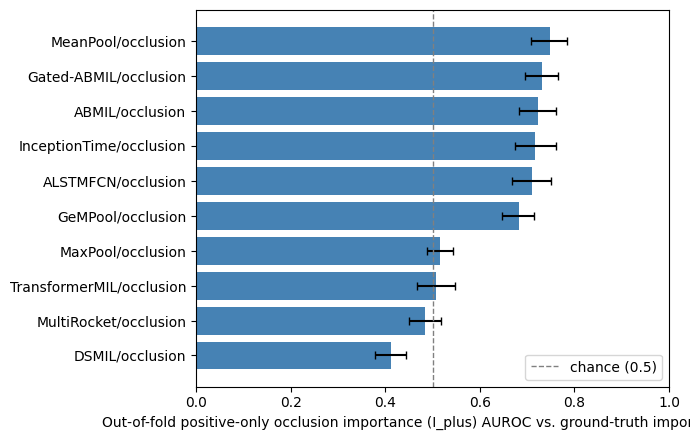

In [18]:
occ_rows = results_df[results_df["signal"].str.endswith("/occlusion")].copy()
occ_rows["mean"] = occ_rows["AUROC [CI]"].apply(lambda s: float(s.split(" [")[0]))
occ_rows["lo"] = occ_rows["AUROC [CI]"].apply(lambda s: float(s.split("[")[1].split(",")[0]))
occ_rows["hi"] = occ_rows["AUROC [CI]"].apply(lambda s: float(s.split(", ")[1].strip("]")))
occ_rows = occ_rows.sort_values("mean")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(occ_rows["signal"], occ_rows["mean"],
        xerr=[occ_rows["mean"] - occ_rows["lo"], occ_rows["hi"] - occ_rows["mean"]],
        color="steelblue", capsize=3)
ax.axvline(0.5, color="gray", linestyle="--", linewidth=1, label="chance (0.5)")
ax.set_xlabel("Out-of-fold positive-only occlusion importance (I_plus) AUROC vs. ground-truth important slices")
ax.set_xlim(0, 1)
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(PLOT_PATH, dpi=150)
plt.show()


### One study, three signals: a qualitative sanity check

Per-slice curves for a single ground-truth study: out-of-fold positive-only
occlusion importance (`I_plus`, MeanPool), ABMIL attention, and DSMIL
instance score, with the true important slices shaded. The study's `fold`
(recorded in `xai_oof`) is the outer fold whose held-out model produced
these numbers -- not one that trained on this study.


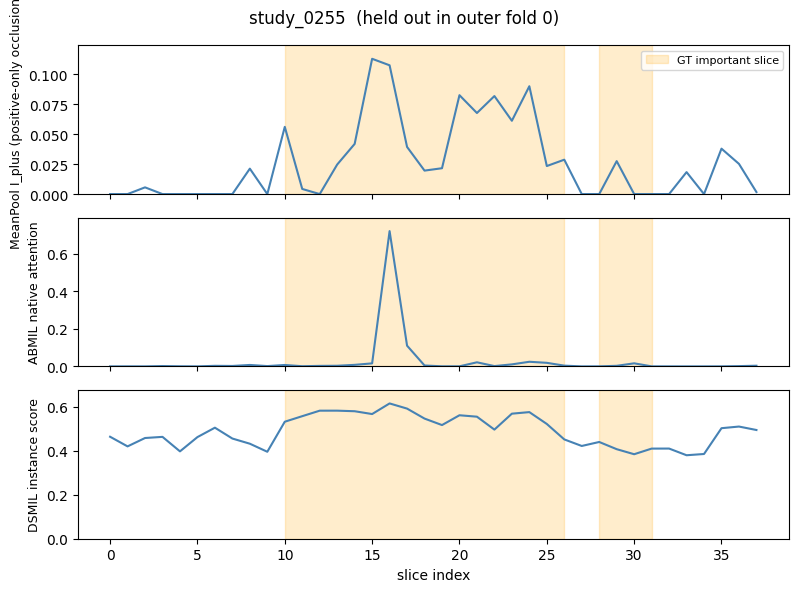

In [19]:
example_id = gt_ids[0]
example_fold = xai_oof["MeanPoolClassifier"][example_id]["fold"]
gt = gt_labels[example_id]
n_slices = len(gt)

occ = positive_only_by_head["MeanPoolClassifier"][example_id]
abmil_attn = xai_oof["ABMILClassifier"][example_id]["native_attention"]
dsmil_inst = dsmil_instance_oof[example_id]

fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=True)
for ax, values, title in zip(
    axes, [occ, abmil_attn, dsmil_inst],
    ["MeanPool I_plus (positive-only occlusion)", "ABMIL native attention", "DSMIL instance score"],
):
    ax.plot(range(n_slices), values, color="steelblue")
    ax.fill_between(range(n_slices), 0, values.max() * 1.1, where=gt.astype(bool),
                    color="orange", alpha=0.2, step="mid", label="GT important slice")
    ax.set_ylabel(title, fontsize=9)
    ax.set_ylim(0, values.max() * 1.1)
axes[0].legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("slice index")
fig.suptitle(f"{example_id}  (held out in outer fold {example_fold})")
fig.tight_layout()
fig.savefig(EXAMPLE_PLOT_PATH, dpi=150)
plt.show()


## Results

Part D's results table (`xai_nested_cv_results_table.csv`), sorted by
occlusion AUROC descending, over all 50 ground-truth-annotated studies in
`prepared_embeddings_full_with_mask.h5`, each scored **out-of-fold** (50/50
valid for every signal -- no study had `K == 0`, `K == N`, or an
all-one-class GT vector). AUROC null (chance) = 0.500; P@K null (mean K/N)
= 0.383. Total nested CV + out-of-fold XAI runtime: 0.17 hours (~10 min).

| Signal | AUROC [CI] | P@K [CI] | null (K/N) | lift [CI] |
|---|---|---|---|---|
| MeanPool/occlusion | 0.748 [0.709, 0.785] | 0.601 [0.542, 0.658] | — | — |
| Gated-ABMIL/occlusion | 0.731 [0.696, 0.765] | 0.602 [0.542, 0.658] | — | — |
| ABMIL/occlusion | 0.723 [0.682, 0.761] | 0.567 [0.500, 0.634] | — | — |
| InceptionTime/occlusion | 0.717 [0.674, 0.760] | 0.589 [0.527, 0.647] | — | — |
| ALSTMFCN/occlusion | 0.710 [0.667, 0.751] | 0.567 [0.501, 0.629] | — | — |
| DSMIL/instance | 0.683 [0.634, 0.728] | 0.540 [0.470, 0.604] | — | — |
| GeMPool/occlusion | 0.682 [0.647, 0.714] | 0.535 [0.473, 0.593] | — | — |
| Gated-ABMIL/attention | 0.664 [0.613, 0.708] | 0.520 [0.461, 0.576] | 0.383 | 1.395 [1.172, 1.639] |
| ABMIL/attention | 0.592 [0.532, 0.648] | 0.459 [0.393, 0.524] | 0.383 | 1.110 [0.914, 1.313] |
| MaxPool/occlusion | 0.515 [0.488, 0.543] | 0.393 [0.337, 0.449] | — | — |
| TransformerMIL/occlusion | 0.507 [0.468, 0.547] | 0.361 [0.295, 0.428] | — | — |
| MultiRocket/occlusion | 0.483 [0.451, 0.518] | 0.331 [0.270, 0.393] | — | — |
| DSMIL/occlusion | 0.412 [0.379, 0.443] | 0.264 [0.213, 0.320] | — | — |
| DSMIL/attention | 0.372 [0.324, 0.424] | 0.283 [0.224, 0.344] | 0.383 | 0.474 [0.284, 0.703] |

**Step 9 orientation checks, out-of-fold:** occlusion sign-check flagged
**MaxPool** (-0.0017), **DSMIL** (-0.0003), and **TransformerMIL** (-0.0012,
newly flagged here -- it barely *passed* at +0.0001 in the single-split
`xai_positive_only.ipynb` run). Attention concentration flagged **DSMIL**
only (GT mean 0.0115 vs. off-GT 0.0349), consistent with both single-split
notebooks.

**What's different from `xai_positive_only.ipynb`'s single-split `I_plus`
numbers, empirically:**

1. **Almost every occlusion and attention AUROC dropped somewhat** under
   out-of-fold nested-CV scoring -- expected, since a single train/val/test
   split's test-fold performance can partly reflect that specific split
   being favorable, while pooling 5 out-of-fold estimates is a stricter,
   more honest measure of generalization. Notable drops: TransformerMIL
   0.555→0.507 (-0.048, and flips from passing to failing the sign check),
   GeMPool 0.716→0.682 (-0.034), DSMIL/occlusion 0.476→0.412 (-0.064),
   ABMIL/attention 0.632→0.592 (-0.040), Gated-ABMIL/occlusion 0.758→0.731
   (-0.027).
2. **DSMIL/attention is a partial exception**: 0.285→0.372 (+0.087) — still
   well below chance and still fails Step 9's attention-concentration
   check, but the anti-correlation is somewhat less extreme when averaged
   out-of-fold across 5 different fitted models than under one single
   split's model.
3. **ALSTMFCN/occlusion and Gated-ABMIL/attention are roughly flat**
   (0.696→0.710, 0.657→0.664) — the two signals least sensitive to which
   split scored them.
4. **The overall ranking is largely preserved**: occlusion signals
   (MeanPool, Gated-ABMIL, ABMIL, InceptionTime, ALSTMFCN) still dominate
   the top of the table, DSMIL/instance and GeMPool/occlusion sit in the
   middle, and DSMIL/occlusion + DSMIL/attention remain the floor — same
   qualitative picture as the single-split run, just with less optimistic
   point estimates and (for TransformerMIL) a sign flip that a single split
   didn't surface.
5. **DSMIL and MultiRocket remain the two heads at/under chance** for
   out-of-fold `I_plus` occlusion AUROC, same as the single-split run.


## Troubleshooting

- **FileNotFoundError on `H5_PATH`:** confirm
  `notebooks/demo_output/prepared_embeddings_full_with_mask.h5` exists (copy
  it from the repo root's `prepared_embeddings_full_with_mask.h5` if not),
  or point `H5_PATH` at your own store with `important_slices` populated.
- **`validate_h5` raises "No samples with split='train'/'test'"**: the store
  needs at least one sample in each of the `train` and `test` splits (even
  though this notebook pools all splits together afterward).
- **XAI OOF coverage assertion fails in Step 5b**: means a GT-annotated
  study didn't get scored by any fold, or got scored by more than one — this
  would indicate the outer folds don't actually partition the cohort
  cleanly; re-check Step 4's coverage asserts ran successfully first.
- **AUROC / P@K is NaN for a study**: expected when a study has no true
  important slices (`K == 0`) or is fully annotated (`K == N`) — both are
  excluded from the aggregate, not treated as zero.
- **A study's `I_plus` is all (numerically) zero for a head**: expected when
  every slice in that study has a non-positive `signed_importance` for that
  head under whichever fold scored it — not a bug, see
  `xai_positive_only.ipynb`'s troubleshooting entry for the same case.
- **`native_attention` is `None` for a head**: only heads with
  `supports_native_attention = True` produce it (ABMIL, Gated-ABMIL, DSMIL
  always; Transformer-MIL only if configured with `pooling="attention"`,
  which this `experiment.yaml` doesn't use).
- **CUDA not available:** `DEVICE` falls back to `"cpu"` automatically — the
  neural heads (and this notebook's added occlusion LOO passes) just run
  much more slowly.
- **Kernel/terminal closed mid-run:** re-running from Step 5 restarts the
  search from scratch; `FOLD_METRICS_CHECKPOINT_PATH`, `OOF_PRED_CHECKPOINT_PATH`,
  `OOF_XAI_CHECKPOINT_PATH`, and `OOF_DSMIL_INSTANCE_CHECKPOINT_PATH` hold
  whatever was written before the interruption, if you want to inspect
  partial results instead of waiting for a full rerun.
- **Step 9 prints `FAIL` for a head**: that head's out-of-fold
  `signed_importance` (or MIL attention) anti-correlates with the ground
  truth on average — read `xai_positive_only.ipynb`'s "How to read a FAIL
  above" before assuming it's a bug; it may be a real property of that
  head's trained models, not code.


## Conclusion

In this notebook we ran nested cross-validation (5 outer folds, 3 inner
folds, `GridSearchCV`/`RandomizedSearchCV` directly on every enabled
`sliceheads` classification head, per `experiment.yaml`) over the full
1063-scan pooled cohort in `prepared_embeddings_full_with_mask.h5`, and, for
each of the 50 ground-truth-annotated studies, computed leave-one-out
occlusion importance and native attention using only the outer fold's model
that held that study out — never one that trained on it, directly or via
inner-fold hyperparameter selection. Each fold's occlusion baseline (mean
embedding) was computed from that fold's outer-training samples only. As in
`xai_positive_only.ipynb`, occlusion was scored with the positive-only
transform `I_plus[k] = max(signed_importance[k], 0) / (sum_j
max(signed_importance[j], 0) + epsilon)`, not the package's `importance`
field; native attention and DSMIL's instance stream were scored unchanged.
Pooling all 5 folds' out-of-fold results gave one localization table over
all 50 studies — every number in it is an out-of-fold estimate.

To compare against the single-split notebooks, run `xai_localization.ipynb`
(`importance`-based) and `xai_positive_only.ipynb` (`I_plus`-based, single
split) and compare their results tables against this notebook's
`xai_nested_cv_results_table.csv`. To reuse this workflow on a different
cohort, point `H5_PATH` at another store with `important_slices` populated
and rerun top to bottom.
